# Customer Churn Prediction using Logistic Regression

### otebook 04 - Feature Engineering & Model Training

---

### Introduction

After understanding, cleaning, and exploring the dataset, the next stage in the machine learning workflow is Feature Engineering and Model Training.

Feature Engineering transforms raw data into a suitable format for machine learning algorithms. This includes separating the features and target variable, encoding categorical variables, scaling numerical features, and preparing the data for training.

Once the data has been prepared, we will build a Logistic Regression model, evaluate its performance using multiple classification metrics, and save the trained model for deployment.

---

### Learning Objectives

By the end of this notebook, you will be able to:

- Load the cleaned dataset
- Separate features and target variable
- Encode categorical variables
- Scale numerical features
- Split the dataset into training and testing sets
- Build a preprocessing pipeline
- Train a Logistic Regression model
- Evaluate model performance
- Save the trained model

### Step 1 - Import Required Libraries

Before building the machine learning model, we import all the required libraries.

These libraries provide functionality for data manipulation, preprocessing, model building, evaluation, visualization, and model serialization.

In [50]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

### Step 2 - Load the Cleaned Dataset

Rather than using the original raw dataset, we load the cleaned dataset generated during the preprocessing stage.

Using the cleaned dataset ensures that unnecessary columns, missing values, and inconsistent data have already been handled.

In [51]:
df = pd.read_excel("D:\\machine learning\\machine_learning\\logistic_regression_project\\churn_prediction\\data\\processed_data\\clean_churn.xlsx")

### Step 3 - Verify the Dataset

Before beginning feature engineering, we verify that the dataset has been loaded correctly.

Checking the structure of the dataset helps ensure that all preprocessing steps were completed successfully.

In [52]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1


In [53]:
df.tail()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7042,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,...,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0


In [54]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"], errors="coerce"
).fillna(0)

### Step 4 - Separate Features and Target Variable

Machine learning models learn relationships between the input features and the target variable.

The **feature matrix (X)** contains all independent variables that help the model make predictions.

The **target variable (y)** contains the outcome that the model is expected to predict.

For this project:

- **X** contains all customer-related information.
- **y** contains the customer churn status.

Separating features and the target variable is the first step before encoding, scaling, and training the model.

In [55]:
# 1. Define target (y)
y = df["Churn Value"]

# 2. Define features (X) — EXCLUDE BOTH target columns!
X = df.drop(columns=["Churn Value", "Churn Label"])

In [56]:
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (7043, 19)
Target Shape : (7043,)


### Observation

The dataset has been successfully divided into the feature matrix (**X**) and the target variable (**y**).

From this point onward, all preprocessing operations will be performed only on the feature matrix, while the target variable will be encoded separately.

### Step 5 - Identify Numerical and Categorical Features

Machine learning algorithms process different types of data in different ways.

Before applying preprocessing techniques, we must identify which features are **categorical** and which are **numerical**.

### Numerical Features

Numerical features contain quantitative values such as integers or decimal numbers. These features can be used for mathematical calculations and are often scaled before training the model.

Examples include:

- Tenure Months
- Monthly Charges
- Total Charges

### Categorical Features

Categorical features represent labels or categories rather than numerical quantities. Since machine learning algorithms cannot directly interpret text values, these features must be converted into numerical representations using encoding techniques.

Examples include:

- Gender
- Partner
- Dependents
- Contract
- Internet Service
- Payment Method

Identifying feature types allows us to apply the correct preprocessing techniques to each group of variables.

In [57]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\n" + "="*60)

print("Numerical Features:")
print(numerical_features)

Categorical Features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical Features:
['Tenure Months', 'Monthly Charges', 'Total Charges']


### Observation

The dataset has been successfully divided into categorical and numerical feature groups.

Categorical features will be transformed using an encoding technique, while numerical features will be standardized before model training.

### Step 6 - Encode the Target Variable

The target variable represents the class that our model will predict.

Currently, the **Churn Label** column contains text values:

- Yes
- No

Machine learning algorithms require the target variable to be numerical. Therefore, we convert these categorical labels into numeric values using **Label Encoding**.

The mapping is as follows:

- Yes → 1
- No → 0

Unlike input features, the target variable has only two classes, making Label Encoding an appropriate choice.

In [58]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

verify

In [59]:
print(label_encoder.classes_)

[0 1]


In [60]:
print(pd.Series(y).value_counts())

0    5174
1    1869
Name: count, dtype: int64


### Step 7 - Split the Dataset

Machine learning models should be evaluated on unseen data.

To achieve this, the dataset is divided into two subsets:

### Training Set

The training dataset is used by the model to learn the relationship between the input features and the target variable.

### Testing Set

The testing dataset is reserved for evaluating how well the trained model performs on new, unseen data.

In this project:

- 80% of the data is used for training.
- 20% of the data is used for testing.

The `stratify` parameter is used to preserve the original class distribution in both subsets, ensuring a fair evaluation.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [62]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (5634, 19)
Testing Features  : (1409, 19)

Training Labels : (5634,)
Testing Labels  : (1409,)


### Step 8 - Build the Data Preprocessing Pipeline

Different types of features require different preprocessing techniques.

### Categorical Features

Categorical variables cannot be directly interpreted by machine learning algorithms. We convert these features into numerical representations using **One-Hot Encoding**.

### Numerical Features

Numerical variables often have different scales. Features with larger values can dominate the learning process. To ensure all numerical features contribute equally, we standardize them using **StandardScaler**.

Instead of applying these transformations manually, we combine them into a **ColumnTransformer**.

Using a preprocessing pipeline offers several advantages:

- Prevents data leakage
- Applies transformations consistently
- Simplifies model deployment
- Improves code readability and maintainability

In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

verify

In [64]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

### Step 9 - Create the Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for **binary classification problems**.

Unlike Linear Regression, which predicts continuous numerical values, Logistic Regression predicts the probability that an observation belongs to a particular class.

In this project, the model predicts whether a customer is likely to:

- Churn (Yes)
- Not Churn (No)

Internally, Logistic Regression uses the **Sigmoid Function**, which converts any numerical value into a probability between **0 and 1**.

The predicted probability is then compared with a decision threshold (typically 0.5) to determine the final class.

In [65]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [66]:
logistic_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Step 10 - Build the Machine Learning Pipeline

A Machine Learning Pipeline combines all preprocessing steps and the model into a single workflow.

Instead of manually applying encoding, scaling, and model training separately, the pipeline performs each transformation automatically in the correct order.

Benefits of using a Pipeline include:

- Prevents data leakage
- Simplifies training and prediction
- Keeps preprocessing consistent
- Makes deployment easier
- Reduces repetitive code

In [67]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

In [68]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

### Step 11 - Train the Model

Training is the process in which the machine learning algorithm learns patterns from historical data.

During training, the pipeline performs the following operations automatically:

1. Encode categorical variables.
2. Scale numerical variables.
3. Fit the Logistic Regression model.
4. Learn the relationship between customer attributes and churn.

After training, the model will be able to make predictions on previously unseen customer data.

In [69]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

### Step 12 - Make Predictions

After training, the model can be used to predict customer churn for unseen observations.

Two types of predictions are commonly generated:

- **Class Prediction** – Predicts whether the customer will churn.
- **Probability Prediction** – Predicts the probability that a customer belongs to each class.

In [70]:
y_pred = pipeline.predict(X_test)

In [71]:
y_probability = pipeline.predict_proba(X_test)

In [72]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction_df.head()

,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0


In [73]:
pd.DataFrame(
    y_probability,
    columns=["No Churn Probability", "Churn Probability"]
).head()

,No Churn Probability,Churn Probability
0,0.922999,0.077001
1,0.327276,0.672724
2,0.899065,0.100935
3,0.523902,0.476098
4,0.968693,0.031307


### Step 13 - Evaluate Model Performance

After training the model, it is important to evaluate how well it performs on unseen data.

The first evaluation metric is **Accuracy**.

### What is Accuracy?

Accuracy represents the proportion of correctly classified observations out of the total number of observations.

It is calculated as:

Accuracy = (Correct Predictions) / (Total Predictions)

Although accuracy is simple to understand, it should not be used as the only evaluation metric, especially when working with imbalanced datasets. Therefore, additional evaluation metrics will also be explored in the following sections.

In [74]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy : {accuracy:.4f}")
print(f"Accuracy Percentage : {accuracy*100:.2f}%")

Model Accuracy : 0.8020
Accuracy Percentage : 80.20%


### Step 14 - Confusion Matrix

A Confusion Matrix provides a detailed summary of the model's predictions by comparing the predicted labels with the actual labels.

Unlike accuracy, the confusion matrix allows us to understand the different types of prediction errors made by the model.

The four possible outcomes are:

- **True Positive (TP):** Customer churned and the model predicted churn.
- **True Negative (TN):** Customer did not churn and the model predicted no churn.
- **False Positive (FP):** Customer did not churn but the model predicted churn.
- **False Negative (FN):** Customer churned but the model predicted no churn.

The confusion matrix is one of the most informative tools for evaluating classification models.

In [76]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[917, 118],
       [161, 213]])

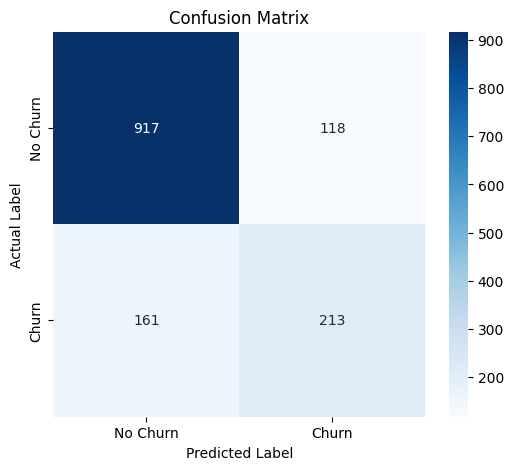

In [77]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

### Step 15 - Classification Report

The Classification Report provides a more detailed evaluation than accuracy alone.

It includes several important metrics:

### Precision

Precision measures how many customers predicted to churn actually churned.

### Recall

Recall measures how many actual churned customers were correctly identified by the model.

### F1-Score

The F1-score is the harmonic mean of Precision and Recall.

### Support

Support indicates the number of observations belonging to each class.

These metrics provide a comprehensive understanding of model performance and are especially useful when evaluating classification problems.

In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Step 16 - Receiver Operating Characteristic (ROC) Curve

The ROC Curve evaluates the classification performance across different decision thresholds.

The curve compares:

- True Positive Rate (Sensitivity)
- False Positive Rate

A model whose curve stays closer to the upper-left corner generally demonstrates better classification performance.

In [79]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

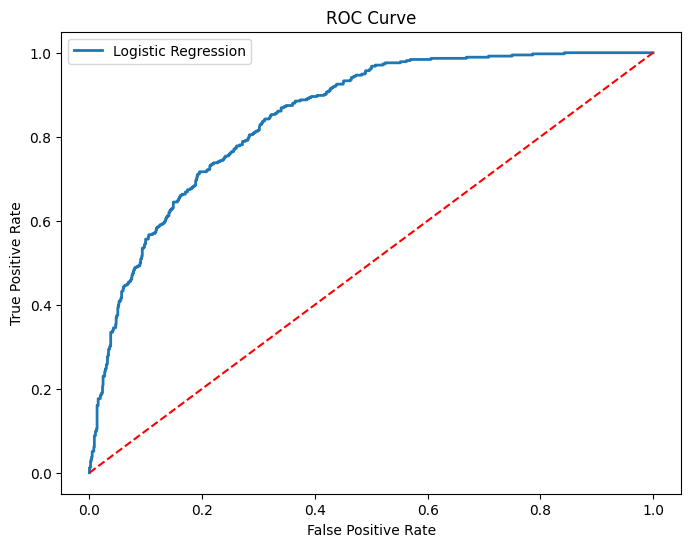

In [80]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, linewidth=2, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--", color="red")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Step 17 - ROC-AUC Score

The Area Under the ROC Curve (AUC) summarizes the model's ability to distinguish between customers who churn and those who do not.

A higher AUC score indicates stronger classification performance.

General interpretation:

- 0.50 → No discrimination
- 0.60–0.70 → Poor
- 0.70–0.80 → Fair
- 0.80–0.90 → Good
- Above 0.90 → Excellent

In [81]:
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score : {auc_score:.4f}")

ROC-AUC Score : 0.8489


### Step 18 - Feature Importance Analysis

Unlike Decision Trees or Random Forests, Logistic Regression does not provide feature importance scores directly.

Instead, it learns a coefficient (weight) for every feature.

Each coefficient indicates how strongly a feature influences the prediction.

### Interpretation

- **Positive Coefficient**
  
  Increases the probability of customer churn.

- **Negative Coefficient**
  
  Decreases the probability of customer churn.

- **Coefficient Near Zero**
  
  Has little influence on the prediction.

By examining these coefficients, we can identify the customer characteristics that most strongly contribute to churn.

In [82]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

coefficients = pipeline.named_steps["classifier"].coef_[0]

In [83]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
43,numerical__Tenure Months,-1.270244,1.270244
7,categorical__Dependents_Yes,-0.989424,0.989424
36,categorical__Contract_Two year,-0.734672,0.734672
6,categorical__Dependents_No,0.645479,0.645479
13,categorical__Internet Service_DSL,-0.608835,0.608835
34,categorical__Contract_Month-to-month,0.563585,0.563585
14,categorical__Internet Service_Fiber optic,0.550165,0.550165
45,numerical__Total Charges,0.521700,0.521700
44,numerical__Monthly Charges,-0.497754,0.497754
37,categorical__Paperless Billing_No,-0.350410,0.350410


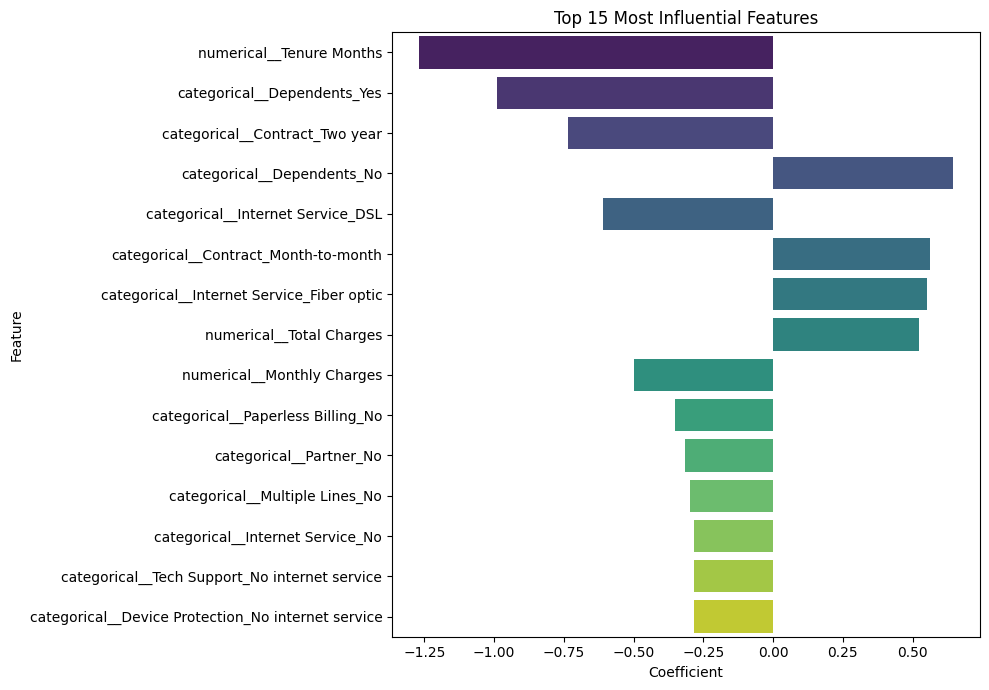

In [84]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Most Influential Features")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [85]:
positive_features = feature_importance.sort_values(
    "Coefficient",
    ascending=False
).head(10)

negative_features = feature_importance.sort_values(
    "Coefficient",
    ascending=True
).head(10)

print("Top Features Increasing Churn")
display(positive_features)

print("\nTop Features Decreasing Churn")
display(negative_features)

Top Features Increasing Churn


,Feature,Coefficient,Absolute Coefficient
6,categorical__Dependents_No,0.645479,0.645479
34,categorical__Contract_Month-to-month,0.563585,0.563585
14,categorical__Internet Service_Fiber optic,0.550165,0.550165
45,numerical__Total Charges,0.521700,0.521700
41,categorical__Payment Method_Electronic check,0.188563,0.188563
30,categorical__Streaming TV_Yes,0.168955,0.168955
33,categorical__Streaming Movies_Yes,0.155942,0.155942
16,categorical__Online Security_No,0.132466,0.132466
25,categorical__Tech Support_No,0.114846,0.114846
12,categorical__Multiple Lines_Yes,0.081648,0.081648



Top Features Decreasing Churn


,Feature,Coefficient,Absolute Coefficient
43,numerical__Tenure Months,-1.270244,1.270244
7,categorical__Dependents_Yes,-0.989424,0.989424
36,categorical__Contract_Two year,-0.734672,0.734672
13,categorical__Internet Service_DSL,-0.608835,0.608835
44,numerical__Monthly Charges,-0.497754,0.497754
37,categorical__Paperless Billing_No,-0.350410,0.350410
4,categorical__Partner_No,-0.317788,0.317788
10,categorical__Multiple Lines_No,-0.299459,0.299459
15,categorical__Internet Service_No,-0.285275,0.285275
26,categorical__Tech Support_No internet service,-0.285275,0.285275


### Step 19 - Save the Trained Model

After successfully training and evaluating the Logistic Regression model, the final step is to save the trained pipeline.

Saving the entire pipeline provides several advantages:

- Preserves the preprocessing steps.
- Preserves the trained Logistic Regression model.
- Ensures consistent predictions during deployment.
- Eliminates the need to retrain the model every time the application starts.

The saved pipeline can later be loaded directly into the Streamlit application for real-time customer churn prediction.

In [86]:
joblib.dump(
    pipeline,
    "D:\machine learning\machine_learning\logistic_regression_project\churn_prediction\models\customer_churn_pipeline.joblib"
)

['D:\\machine learning\\machine_learning\\logistic_regression_project\\churn_prediction\\models\\customer_churn_pipeline.joblib']

In [87]:
joblib.dump(
    label_encoder,
    "D:\machine learning\machine_learning\logistic_regression_project\churn_prediction\models\label_encoder.joblib"
)

['D:\\machine learning\\machine_learning\\logistic_regression_project\\churn_prediction\\models\\label_encoder.joblib']

# Final Summary

## Project Workflow Completed

This notebook completed the feature engineering, model training, and evaluation stages of the Customer Churn Prediction project.

The following workflow was performed successfully:

### Data Preparation

- Loaded the cleaned dataset.
- Separated the feature matrix and target variable.
- Identified numerical and categorical features.

### Feature Engineering

- Encoded the target variable.
- Applied One-Hot Encoding to categorical features.
- Standardized numerical features.
- Built a preprocessing pipeline.

### Model Development

- Split the dataset into training and testing sets.
- Built a Logistic Regression classifier.
- Combined preprocessing and classification into a single machine learning pipeline.
- Trained the model using historical customer data.

### Model Evaluation

The model was evaluated using multiple classification metrics, including:

- Accuracy Score
- Confusion Matrix
- Classification Report
- ROC Curve
- ROC-AUC Score

Additionally, Logistic Regression coefficients were analyzed to understand the factors influencing customer churn.

### Model Persistence

The trained pipeline and label encoder were saved using Joblib, making them ready for deployment.

---

## Conclusion

The Logistic Regression model successfully learned the relationship between customer characteristics and churn behavior.

The trained pipeline is now ready to be integrated into a Streamlit application, where users can enter customer information and receive real-time churn predictions.

This notebook demonstrates a complete end-to-end supervised machine learning workflow, covering data preprocessing, feature engineering, model development, evaluation, interpretation, and deployment preparation.